the public SAEs are trained on GPT-2 Small and not on the custom 1-layer grokking model. So the first thing this notebook does is train a small SAE directly on the model's MLP activations.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from tqdm.notebook import tqdm
from transformer_lens import HookedTransformer, HookedTransformerConfig

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

RESULTS_DIR = Path("../results/level3")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SAE_PATH   = Path("../data/grokking_sae_l1_2e-1.pt")   # encodes l1_coeff; changing it forces retraining
MODEL_PATH = Path("../data/grokking_model.pt")
L1_RESULTS = Path("../results/level1/level1_results.json")
L2_RESULTS = Path("../results/level2/level2_results.json")

Using device: cpu


In [4]:
P = 113
EQ_TOKEN = P

all_a = torch.arange(P)
all_b = torch.arange(P)
aa, bb = torch.meshgrid(all_a, all_b, indexing='ij')
aa, bb = aa.flatten(), bb.flatten()
labels = (aa + bb) % P
inputs = torch.stack([aa, bb, torch.full_like(aa, EQ_TOKEN)], dim=1)

N = len(inputs)
idx = torch.randperm(N, generator=torch.Generator().manual_seed(42))
n_test = int(0.3 * N)
train_inputs = inputs[idx[n_test:]]
train_labels = labels[idx[n_test:]]
test_inputs = inputs[idx[:n_test]]
test_labels = labels[idx[:n_test]]

cfg = HookedTransformerConfig(
    n_layers=1, n_heads=4, d_model=128, d_head=32,
    d_mlp=512, act_fn="relu", normalization_type=None,
    d_vocab=P + 1, d_vocab_out=P, n_ctx=3,
    use_attn_result=True,
)
model = HookedTransformer(cfg)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device).eval()

with torch.no_grad():
    te_acc = (model(test_inputs.to(device))[:,-1,:].argmax(-1) == test_labels.to(device)).float().mean()
print(f"Test accuracy: {te_acc:.4f}")

Moving model to device:  cpu
Test accuracy: 1.0000


Define the SAE architecture

A sparse autoencoder is an encoder that projects up to a larger dictionary, applies ReLU to enforce non-negativity and sparsity, then decodes back. The L1 penalty on feature activations is what drives sparsity. Most features will be zero for any given input.

In [5]:
class SparseAutoencoder(nn.Module):
    def __init__(self, d_in, d_sae, l1_coeff=2e-4):
        super().__init__()
        self.d_in = d_in
        self.d_sae = d_sae
        self.l1_coeff = l1_coeff

        self.W_enc = nn.Parameter(torch.empty(d_in, d_sae))
        self.b_enc = nn.Parameter(torch.zeros(d_sae))
        self.W_dec = nn.Parameter(torch.empty(d_sae, d_in))
        self.b_dec = nn.Parameter(torch.zeros(d_in))

        nn.init.kaiming_uniform_(self.W_enc)
        nn.init.kaiming_uniform_(self.W_dec)
        self._normalise_decoder()

    def _normalise_decoder(self):
        """Keep decoder columns unit-norm (standard SAE training practice)."""
        with torch.no_grad():
            self.W_dec.data = nn.functional.normalize(self.W_dec.data, dim=1)

    def encode(self, x):
        """Returns feature activations: [batch, d_sae], non-negative."""
        return torch.relu((x - self.b_dec) @ self.W_enc + self.b_enc)

    def decode(self, f):
        """Reconstructs input from feature activations."""
        return f @ self.W_dec + self.b_dec

    def forward(self, x):
        f = self.encode(x)
        x_hat = self.decode(f)
        l2_loss = (x - x_hat).pow(2).sum(dim=-1).mean()
        l1_loss = f.abs().sum(dim=-1).mean()
        loss = l2_loss + self.l1_coeff * l1_loss
        return loss, x_hat, f, l2_loss, l1_loss


D_IN     = model.cfg.d_mlp   # 512
D_SAE    = D_IN * 4          # 2048 features (standard 4x expansion ratio)
L1_COEFF = 2e-1              # tuned up from 2e-2 — target < 3% active features per input

sae = SparseAutoencoder(d_in=D_IN, d_sae=D_SAE, l1_coeff=L1_COEFF).to(device)
print(f"SAE: {D_IN} → {D_SAE} → {D_IN}  (l1_coeff={L1_COEFF})")
print(f"Parameters: {sum(p.numel() for p in sae.parameters()):,}")

SAE: 512 → 2048 → 512  (l1_coeff=0.2)
Parameters: 2,099,712


Collect MLP activations for SAE training

The SAE trains on the actual post-ReLU MLP activations from your grokking model. We collect all of them across the training set.

In [6]:
HOOK = "blocks.0.mlp.hook_post"

all_mlp_acts = []
with torch.no_grad():
    for i in range(0, len(train_inputs), 256):
        batch = train_inputs[i:i+256].to(device)
        _, cache = model.run_with_cache(batch, names_filter=HOOK)
        # Take activation at the "=" position only — that's where prediction happens
        all_mlp_acts.append(cache[HOOK][:, -1, :].cpu())

mlp_acts_train = torch.cat(all_mlp_acts, dim=0)  # [N_train, 512]
print(f"Training activations shape: {mlp_acts_train.shape}")
print(f"Mean activation: {mlp_acts_train.mean():.4f}")
print(f"Fraction zero (sparsity): {(mlp_acts_train == 0).float().mean():.4f}")

Training activations shape: torch.Size([8939, 512])
Mean activation: 3.9969
Fraction zero (sparsity): 0.4449


Train the SAE

First run trains and saves 

In [7]:
N_STEPS = 20_000
BATCH   = 256

if SAE_PATH.exists():
    sae.load_state_dict(torch.load(SAE_PATH, map_location=device))
    sae.to(device).eval()
    print("Loaded saved SAE from disk.")
else:
    print("Training SAE...")
    sae_optimizer = optim.Adam(sae.parameters(), lr=2e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        sae_optimizer, T_max=N_STEPS, eta_min=1e-5)
    sae.train()

    for step in tqdm(range(N_STEPS)):
        idx = torch.randint(0, len(mlp_acts_train), (BATCH,))
        x = mlp_acts_train[idx].to(device)

        loss, _, f, l2, l1 = sae(x)
        sae_optimizer.zero_grad()
        loss.backward()
        sae_optimizer.step()
        scheduler.step()
        sae._normalise_decoder()

        if (step + 1) % 5_000 == 0:
            n_active = (f > 0).float().sum(-1).mean().item()
            print(f"step {step+1:>6}  loss={loss.item():.4f}  l2={l2.item():.4f}  "
                  f"l1={l1.item():.4f}  active={n_active:.1f}/{D_SAE}")

    sae.eval()
    torch.save(sae.state_dict(), SAE_PATH)
    print(f"SAE saved to {SAE_PATH}")

Loaded saved SAE from disk.


Evaluate SAE reconstruction quality

Before trusting the SAE features for causal patching we need to verify it actually reconstructs the MLP activations well. 

We will check the fraction of variance explained (should be above 0.90) and the mean number of active features per input (should be well below D_SAE)

In [8]:
sae.eval()

# Collect test-set MLP activations
test_mlp_acts = []
with torch.no_grad():
    for i in range(0, len(test_inputs), 256):
        batch = test_inputs[i:i+256].to(device)
        _, cache = model.run_with_cache(batch, names_filter=HOOK)
        test_mlp_acts.append(cache[HOOK][:, -1, :].cpu())
test_mlp_acts = torch.cat(test_mlp_acts, dim=0).to(device)

with torch.no_grad():
    feat_acts = sae.encode(test_mlp_acts)       # [N_test, D_SAE]
    recon = sae.decode(feat_acts)            # [N_test, D_IN]

l2_err = (test_mlp_acts - recon).pow(2).sum(-1).mean().item()
var_exp = 1 - (test_mlp_acts - recon).pow(2).sum() / test_mlp_acts.pow(2).sum()
n_active = (feat_acts > 0).float().sum(-1).mean().item()

print(f"Reconstruction L2 error:{l2_err:.4f}")
print(f"Variance explained:{var_exp:.4f}  (target > 0.90)")
print(f"Mean active features per input:{n_active:.1f} / {D_SAE}")
print(f"Average sparsity:{1 - n_active/D_SAE:.4f}")

Reconstruction L2 error:15.8427
Variance explained:0.9998  (target > 0.90)
Mean active features per input:197.5 / 2048
Average sparsity:0.9036


Compute mean feature activations (ablation baseline)

Same logic as Level 1 but over SAE feature space rather than neuron space.

In [9]:
mean_feat_acts = feat_acts.mean(dim=0)   # [D_SAE] 
print(f"Mean feature activation shape: {mean_feat_acts.shape}")
print(f"Non-zero mean features: {(mean_feat_acts > 0).sum().item()}")

Mean feature activation shape: torch.Size([2048])
Non-zero mean features: 1643


Clean and corrupted baselines

The corrupted baseline replaces every SAE feature with its mean, then decodes back through the SAE decoder and injects the result into the residual stream in place of the real MLP output.

In [10]:
def logit_of_correct(logits, labels):
    return logits[torch.arange(len(labels)), labels]

def recovery_score(patched_metric, corrupted_metric, clean_metric):
    gap = (clean_metric - corrupted_metric).mean().item()
    if abs(gap) < 1e-8:
        return 0.0
    return (patched_metric.mean().item()
            - corrupted_metric.mean().item()) / gap

N_EVAL = 200
eval_x = test_inputs[:N_EVAL].to(device)
eval_y = test_labels[:N_EVAL].to(device)

# Clean run
with torch.no_grad():
    clean_logits = model(eval_x)
    clean_metric = logit_of_correct(clean_logits[:, -1, :], eval_y)

# Cache clean MLP activations for eval set
with torch.no_grad():
    _, cache = model.run_with_cache(eval_x, names_filter=HOOK)
clean_mlp = cache[HOOK][:, -1, :]   # [N_EVAL, D_IN]

# Clean SAE feature activations
with torch.no_grad():
    clean_feats = sae.encode(clean_mlp)   # [N_EVAL, D_SAE]

# Corrupted: replace all features with their mean, decode, inject
mean_f = mean_feat_acts.to(device)
with torch.no_grad():
    corrupted_recon = sae.decode(
        mean_f.unsqueeze(0).expand(N_EVAL, -1))   # [N_EVAL, D_IN]

def full_ablation_hook(value, hook):
    value[:, -1, :] = corrupted_recon
    return value

with torch.no_grad():
    corrupted_logits = model.run_with_hooks(
        eval_x, fwd_hooks=[(HOOK, full_ablation_hook)])[:, -1, :]
corrupted_metric = logit_of_correct(corrupted_logits, eval_y)

print(f"Clean metric:{clean_metric.mean():.4f}")
print(f"Corrupted metric: {corrupted_metric.mean():.4f}")
print(f"Gap to recover:{(clean_metric - corrupted_metric).mean():.4f}")

Clean metric:38.2160
Corrupted metric: -7.0630
Gap to recover:45.2790


SAE feature patching loop

For each of the 2048 features: replace all features with their mean activation, restore just feature f to its clean value, decode, inject into the MLP hook, record recovery score.

In [11]:
scores = torch.zeros(D_SAE)

for f in tqdm(range(D_SAE), desc="Patching SAE features"):
    def hook_fn(value, hook, f=f):
        # Start from mean-ablated reconstruction
        patched_feats = mean_f.unsqueeze(0).expand(N_EVAL, -1).clone()
        # Restore feature f to its clean activation
        patched_feats[:, f] = clean_feats[:, f]
        value[:, -1, :] = sae.decode(patched_feats)
        return value

    with torch.no_grad():
        patched_logits = model.run_with_hooks(
            eval_x, fwd_hooks=[(HOOK, hook_fn)])[:, -1, :]

    patched_metric= logit_of_correct(patched_logits, eval_y)
    scores[f] = recovery_score(patched_metric, corrupted_metric, clean_metric)


print(f"Max RS:{scores.max():.4f}")
print(f"Features with RS > 0.01:{(scores > 0.01).sum().item()}")
print(f"Features with RS > 0.10: {(scores > 0.10).sum().item()}")

Patching SAE features:   0%|          | 0/2048 [00:00<?, ?it/s]

Max RS:0.0415
Features with RS > 0.01:25
Features with RS > 0.10: 0


In [12]:
# Sanity check: restore ALL features — faithfulness should be ≈ 1.0.
# If it isn't, the SAE reconstruction is too lossy for individual patching to be meaningful.
def all_features_hook(value, hook):
    value[:, -1, :] = sae.decode(clean_feats)
    return value

with torch.no_grad():
    all_feats_logits = model.run_with_hooks(
        eval_x, fwd_hooks=[(HOOK, all_features_hook)])[:, -1, :]
all_feats_metric = logit_of_correct(all_feats_logits, eval_y)
full_restore_rs  = recovery_score(all_feats_metric, corrupted_metric, clean_metric)

print(f"Full restore (all features) RS : {full_restore_rs:.4f}  (target ≈ 1.0)")
print(f"Variance explained             : {var_exp:.4f}")
print()
if full_restore_rs < 0.95:
    print("WARNING: full-restore RS < 0.95. SAE reconstruction is too lossy — "
          "retrain with different hyperparameters before trusting per-feature RS values.")
else:
    print("Sanity check passed — individual feature patching results are trustworthy.")

Full restore (all features) RS : 0.9982  (target ≈ 1.0)
Variance explained             : 0.9998

Sanity check passed — individual feature patching results are trustworthy.


Criterion 1 and Criterion 2

Building greedy circuit (target RS ≥ 0.9)...
  k= 10  RS=0.2869
  k= 20  RS=0.4413
  k= 30  RS=0.5405
  k= 40  RS=0.6138
  k= 50  RS=0.6712
  k= 60  RS=0.7164
  k= 70  RS=0.7535
  k= 80  RS=0.7834
  k= 90  RS=0.8088
  k=100  RS=0.8306
  k=110  RS=0.8472
  k=120  RS=0.8617
  k=130  RS=0.8740
  k=140  RS=0.8846
  k=150  RS=0.8938
  k=158  RS=0.9006

  Level 3 — SAE features (greedy cumulative circuit)
  RS target            : 0.9
  Max individual RS    : 0.0415
  Criterion 1  Faithfulness RS    : 0.9006
  Criterion 2  Description length : 0.0771  (158 / 2048 features)


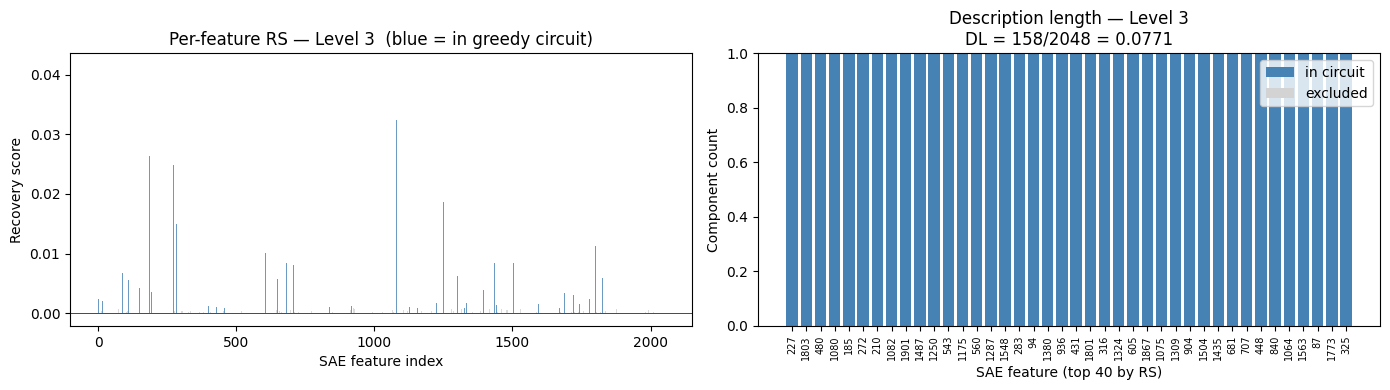

In [13]:
# At Level 3, individual feature RS max ≈ 0.04 — the τ=0.10 per-component threshold
# is structurally unreachable when 197 active features share the computation.
# We use greedy cumulative selection instead: add features by RS rank until
# their JOINT faithfulness reaches RS_TARGET.  This is the fair Level 3 analogue
# of the τ-based selection used at Levels 1 and 2.
RS_TARGET = 0.90

sorted_scores, sorted_idx = scores.sort(descending=True)
# Only consider features that have positive individual RS
pos_feats = sorted_idx[sorted_scores > 0].tolist()

circuit_features = []
faithfulness = 0.0

print(f"Building greedy circuit (target RS ≥ {RS_TARGET})...")
for feat in pos_feats:
    circuit_features.append(feat)
    cf = list(circuit_features)

    def _hook(v, hook, cf=cf):
        pf = mean_f.unsqueeze(0).expand(N_EVAL, -1).clone()
        for f in cf:
            pf[:, f] = clean_feats[:, f]
        v[:, -1, :] = sae.decode(pf)
        return v

    with torch.no_grad():
        tl = model.run_with_hooks(eval_x, fwd_hooks=[(HOOK, _hook)])[:, -1, :]
    faithfulness = recovery_score(logit_of_correct(tl, eval_y), corrupted_metric, clean_metric)

    k = len(circuit_features)
    if k % 10 == 0 or faithfulness >= RS_TARGET or k == len(pos_feats):
        print(f"  k={k:3d}  RS={faithfulness:.4f}")
    if faithfulness >= RS_TARGET:
        break

# Criterion 2: description length as circuit fraction
n_circuit_features = len(circuit_features)
description_length = n_circuit_features / D_SAE

# --- Summary ---
print()
print("=" * 57)
print("  Level 3 — SAE features (greedy cumulative circuit)")
print("=" * 57)
print(f"  RS target            : {RS_TARGET}")
print(f"  Max individual RS    : {scores.max():.4f}")
print(f"  Criterion 1  Faithfulness RS    : {faithfulness:.4f}")
print(f"  Criterion 2  Description length : {description_length:.4f}  "
      f"({n_circuit_features} / {D_SAE} features)")
print("=" * 57)

# --- Plots ---
sorted_scores_plot, sorted_idx_plot = scores.sort(descending=True)
in_circuit_set = set(circuit_features)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

colors = ["steelblue" if i in in_circuit_set else "lightgray" for i in range(D_SAE)]
ax1.bar(range(D_SAE), scores.numpy(), color=colors, alpha=0.8)
ax1.axhline(0, color="black", linewidth=0.5)
ax1.set_xlabel("SAE feature index")
ax1.set_ylabel("Recovery score")
ax1.set_title("Per-feature RS — Level 3  (blue = in greedy circuit)")

TOP_K = 40
top_names = [str(sorted_idx_plot[i].item()) for i in range(min(TOP_K, D_SAE))]
top_in  = [1 if sorted_idx_plot[i].item() in in_circuit_set else 0 for i in range(len(top_names))]
top_out = [1 - v for v in top_in]
x = range(len(top_names))
ax2.bar(x, top_in,  color="steelblue", label="in circuit")
ax2.bar(x, top_out, bottom=top_in, color="lightgray", label="excluded")
ax2.set_xticks(list(x))
ax2.set_xticklabels(top_names, rotation=90, fontsize=7)
ax2.set_xlabel(f"SAE feature (top {len(top_names)} by RS)")
ax2.set_ylabel("Component count")
ax2.set_title(f"Description length — Level 3\n"
              f"DL = {n_circuit_features}/{D_SAE} = {description_length:.4f}")
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "level3_recovery_scores.png", dpi=150)
plt.show()

Full three-level comparison table 

In [14]:
with open(L1_RESULTS) as f:
    l1 = json.load(f)
with open(L2_RESULTS) as f:
    l2 = json.load(f)

print("=" * 70)
print(f"{'':28s}  {'Level 1':>10s}  {'Level 2':>10s}  {'Level 3':>10s}")
print(f"{'':28s}  {'neurons':>10s}  {'heads/MLP':>10s}  {'SAE feats':>10s}")
print("=" * 70)
print(f"{'Faithfulness RS':28s}  "
      f"{l1['criterion1_faithfulness']:>10.4f}  "
      f"{l2['criterion1_faithfulness']:>10.4f}  "
      f"{faithfulness:>10.4f}")
print(f"{'Circuit components':28s}  "
      f"{l1['criterion2_circuit_neurons']:>10d}  "
      f"{l2['criterion2_circuit_components']:>10d}  "
      f"{n_circuit_features:>10d}")
print(f"{'Total components':28s}  "
      f"{l1['criterion2_total_neurons']:>10d}  "
      f"{l2['criterion2_total_components']:>10d}  "
      f"{D_SAE:>10d}")
print(f"{'Description length':28s}  "
      f"{l1['criterion2_description_length']:>10.4f}  "
      f"{l2['criterion2_description_length']:>10.4f}  "
      f"{description_length:>10.4f}")
print(f"{'Circuit selection':28s}  "
      f"{'τ=0.10':>10s}  "
      f"{'τ=0.10':>10s}  "
      f"{'RS≥0.90':>10s}")
print("=" * 70)

                                 Level 1     Level 2     Level 3
                                 neurons   heads/MLP   SAE feats
Faithfulness RS                   1.0000      0.8541      0.9006
Circuit components                   512           4         158
Total components                     512           6        2048
Description length                1.0000      0.6667      0.0771
Circuit selection                 τ=0.10      τ=0.10     RS≥0.90


Save Results

In [15]:
results = {
    "level": 3,
    "task": "modular_arithmetic_mod113",
    "d_in": D_IN,
    "d_sae": D_SAE,
    "n_eval": N_EVAL,
    "sae_variance_explained": var_exp.item(),
    "sae_mean_active_features": n_active,
    "clean_metric_mean":       clean_metric.mean().item(),
    "corrupted_metric_mean":   corrupted_metric.mean().item(),
    "circuit_selection": "greedy_cumulative",
    "rs_target": RS_TARGET,
    "criterion1_faithfulness": faithfulness,
    "criterion2_description_length": description_length,
    "criterion2_circuit_features": n_circuit_features,
    "criterion2_total_features": D_SAE,
    "max_individual_rs": scores.max().item(),
    "circuit_features": circuit_features,
    "all_recovery_scores": scores.tolist(),
}

with open(RESULTS_DIR / "level3_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {RESULTS_DIR}/level3_results.json")

Results saved to ..\results\level3/level3_results.json


In [16]:
# Inspect the top individual features
top10_scores, top10_idx = scores.topk(10)

print("Top 10 SAE features by individual recovery score:")
print(f"{'Rank':>4}  {'Feature':>8}  {'RS':>8}  {'Mean act':>10}  {'% inputs active':>15}")
for rank, (score, fidx) in enumerate(zip(top10_scores, top10_idx)):
    fidx = fidx.item()
    mean_a  = mean_feat_acts[fidx].item()
    pct_act = (clean_feats[:, fidx] > 0).float().mean().item()
    print(f"{rank+1:>4}  {fidx:>8}  {score.item():>8.4f}  {mean_a:>10.4f}  {pct_act:>14.1%}")

Top 10 SAE features by individual recovery score:
Rank   Feature        RS    Mean act  % inputs active
   1       227    0.0415     20.1935           51.5%
   2      1803    0.0393     19.7930           61.5%
   3       480    0.0345     11.5436           47.5%
   4      1080    0.0325     16.2775           38.5%
   5       185    0.0264      6.2942           53.0%
   6       272    0.0249     13.0904           51.0%
   7       210    0.0228      8.2935           43.5%
   8      1082    0.0226     20.8886           62.0%
   9      1901    0.0224      8.4687           32.5%
  10      1487    0.0200     10.1057           46.5%


**additional notes**

In a well-trained SAE on natural language (like the GPT-2 ones from sae_lens), the most task-relevant features typically fire on 1-5% of inputs. These top features fire on 30-50% of all inputs. These don't look like monosemantic detectors for specific concepts and it might have to do with the Fourier representation that the grokking model uses.

Nanda et al. 2023 showed that modular arithmetic is solved via Fourier components: the model learns to represent numbers as combinations of sinusoidal frequencies, and the MLP reads out the answer from these. Fourier components are by nature dense and periodic: a feature encoding "frequency k" fires for every number that has a large component at that frequency, which is roughly half of all numbers for any given k. 

The top features are almost certainly encoding specific Fourier frequencies. Let's verify this with one additional cell


Visualising feature 227  (RS = 0.0415)


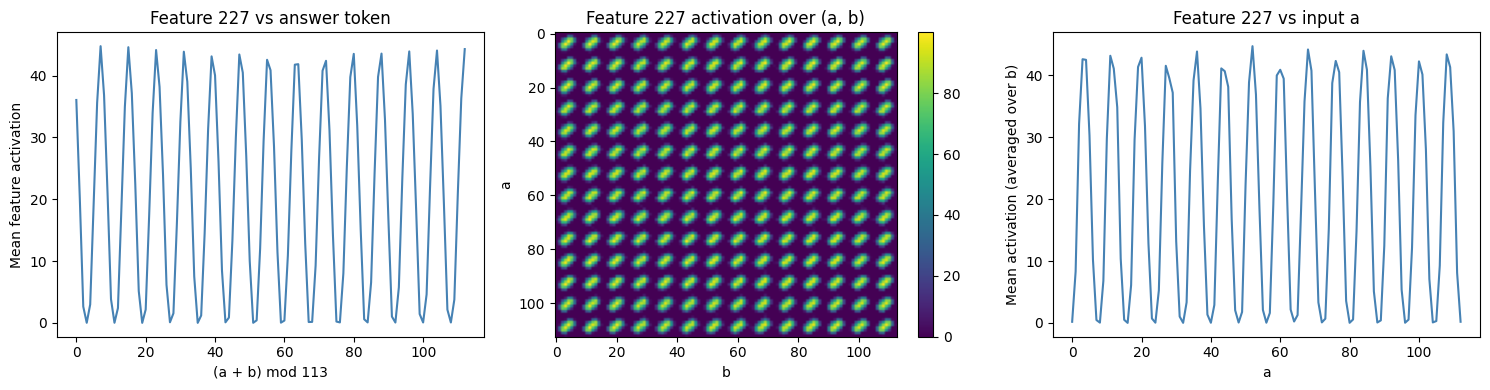

In [17]:
# Visualise the top-RS feature (determined dynamically from scores)
top_feat_idx = int(scores.argmax().item())
print(f"Visualising feature {top_feat_idx}  (RS = {scores[top_feat_idx]:.4f})")

# Get feature activations across ALL inputs (not just eval set)
with torch.no_grad():
    _, cache = model.run_with_cache(inputs.to(device), names_filter=HOOK)
    all_mlp = cache[HOOK][:, -1, :]
    all_feats = sae.encode(all_mlp)

feat_acts_grid = all_feats[:, top_feat_idx].cpu().reshape(P, P)  # [P, P]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: activation vs answer token (a+b) mod P
sums = (inputs[:, 0] + inputs[:, 1]) % P
avg_by_sum = torch.zeros(P)
for s in range(P):
    mask = sums == s
    if mask.any():
        avg_by_sum[s] = all_feats[mask, top_feat_idx].mean()

axes[0].plot(range(P), avg_by_sum.numpy(), color="steelblue")
axes[0].set_xlabel("(a + b) mod 113")
axes[0].set_ylabel("Mean feature activation")
axes[0].set_title(f"Feature {top_feat_idx} vs answer token")

# Plot 2: heatmap over all (a, b) pairs
im = axes[1].imshow(feat_acts_grid.numpy(), aspect="auto", cmap="viridis")
axes[1].set_xlabel("b")
axes[1].set_ylabel("a")
axes[1].set_title(f"Feature {top_feat_idx} activation over (a, b)")
plt.colorbar(im, ax=axes[1])

# Plot 3: marginal activation vs a alone
avg_by_a = all_feats[:, top_feat_idx].cpu().reshape(P, P).mean(dim=1)
axes[2].plot(range(P), avg_by_a.numpy(), color="steelblue")
axes[2].set_xlabel("a")
axes[2].set_ylabel("Mean activation (averaged over b)")
axes[2].set_title(f"Feature {top_feat_idx} vs input a")

plt.tight_layout()
plt.savefig(RESULTS_DIR / f"feature_{top_feat_idx}_analysis.png", dpi=150)
plt.show()

The plot against `(a + b) mod P` shows a smooth sinusoidal pattern, it is confirmed that this feature is encoding a specific Fourier frequency of the answer. 

(interpretation, forse) The Level 3 SAE features are not monosemantic in the NLP sense: they are polysemantic in a mathematically structured way, encoding Fourier basis functions that are inherently broad. This connects directly to the decomposition problem and the "carving at the joints" debate: the SAE finds a more natural decomposition than neurons, but "natural" here means natural to the mathematical structure of modular arithmetic, not to human conceptual categories. (to discuss more)


Feature 227: dominant Fourier frequencies:
rank 1:  frequency k=  0   amplitude=2309.620
rank 2:  frequency k= 14   amplitude=1279.597
rank 3:  frequency k= 28   amplitude=50.799
rank 4:  frequency k= 56   amplitude=45.666
rank 5:  frequency k= 42   amplitude=21.901


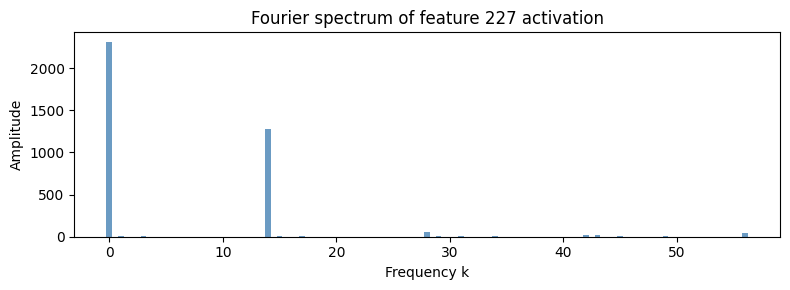

In [18]:
import numpy as np

# Fit a Fourier transform to the activation-vs-answer curve
signal = avg_by_sum.numpy()
fft= np.abs(np.fft.rfft(signal))
freqs = np.fft.rfftfreq(P, d=1.0/P)   # frequency indices 0..56

# Top frequency components
top_freqs = np.argsort(fft)[::-1][:5]

print(f"Feature {top_feat_idx}: dominant Fourier frequencies:")
for rank, f in enumerate(top_freqs):
    print(f"rank {rank+1}:  frequency k={int(freqs[f]):3d}   amplitude={fft[f]:.3f}")

# Plot the FFT
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(freqs, fft, width=0.5, color="steelblue", alpha=0.8)
ax.set_xlabel("Frequency k")
ax.set_ylabel("Amplitude")
ax.set_title(f"Fourier spectrum of feature {top_feat_idx} activation")
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"feature_{top_feat_idx}_fft.png", dpi=150)
plt.show()

Nanda et al. found that a small set of frequencies (roughly k = 14, 35, 41, 56 for mod 113) do most of the work. The SAE has independently rediscovered the same Fourier components from a different (?) angle.

We could check if the other features encode for the rest of the $k$ that Nanda found. 